In [115]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Berikut ini alasan kenapa harus import semua library di atas: import numpy untuk operasi array dan perhitungan matriks, import cv2 untuk membaca citra dan melakukan konversi warna, import matplotlib untuk menampilkan hasil visualisasi citra di setiap tahapan.

Pada tahap ini citra backup.jpg dibaca menggunakan OpenCV dalam dua bentuk, yaitu grayscale untuk proses filtering dan deteksi tepi, serta RGB untuk keperluan visualisasi dan highlight siluet. Grayscale digunakan agar proses filtering dan deteksi tepi lebih mudah dilakukan karena citra hanya memiliki satu channel intensitas.

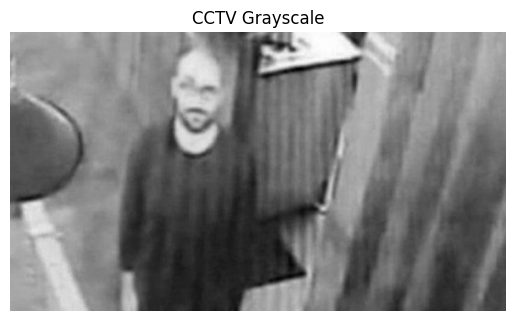

In [116]:
img1 = cv2.imread('backup.jpg', cv2.IMREAD_GRAYSCALE)

img1_bgr = cv2.imread('backup.jpg')
img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img1, cmap='gray')
plt.title('CCTV Grayscale')
plt.axis('off')
plt.show()

In [117]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def normalisasi(img):
    img = img.astype(np.float32)

    min_val = np.min(img)
    max_val = np.max(img)

    if max_val - min_val == 0:
        return np.zeros_like(img, dtype=np.uint8)

    hasil = (img - min_val) * 255 / (max_val - min_val)
    return np.clip(hasil, 0, 255).astype(np.uint8)

Function convolution digunakan untuk melakukan proses konvolusi manual menggunakan kernel tertentu. Proses konvolusi bekerja dengan menggeser kernel ke setiap posisi piksel, mengalikan nilai kernel dengan nilai piksel di area bawahnya secara element-wise, lalu menjumlahkan hasilnya menjadi satu nilai piksel baru. Output function ini bertipe float32 dan belum dinormalisasi karena normalisasi dilakukan secara terpisah sesuai kebutuhan. Untuk smoothing dan sharpening dilakukan clipping ke rentang 0-255 agar nilai tidak keluar batas uint8, sedangkan untuk deteksi tepi dilakukan normalisasi penuh ke 0-255 berdasarkan nilai maksimum gradien agar tepi dapat ditampilkan dengan kontras yang maksimal. Function ini digunakan pada smoothing, sharpening, dan deteksi tepi seperti Sobel, Prewitt, dan Roberts.

Pada tahap ini dilakukan dua jenis perbaikan kualitas citra sekaligus dengan filter statistik dan kernel konvolusi. Smoothing digunakan untuk menghaluskan citra dengan meratakan nilai piksel di sekitarnya sehingga noise berkurang dan transisi intensitas menjadi lebih lembut. Sharpening digunakan untuk memperjelas detail dan meningkatkan kontras pada citra sehingga garis dan detail objek terlihat lebih tegas dibandingkan citra asli. Kombinasi smoothing kemudian sharpening menghasilkan citra yang lebih bersih sekaligus lebih tajam karena noise dihilangkan terlebih dahulu sebelum detail dipertegas.

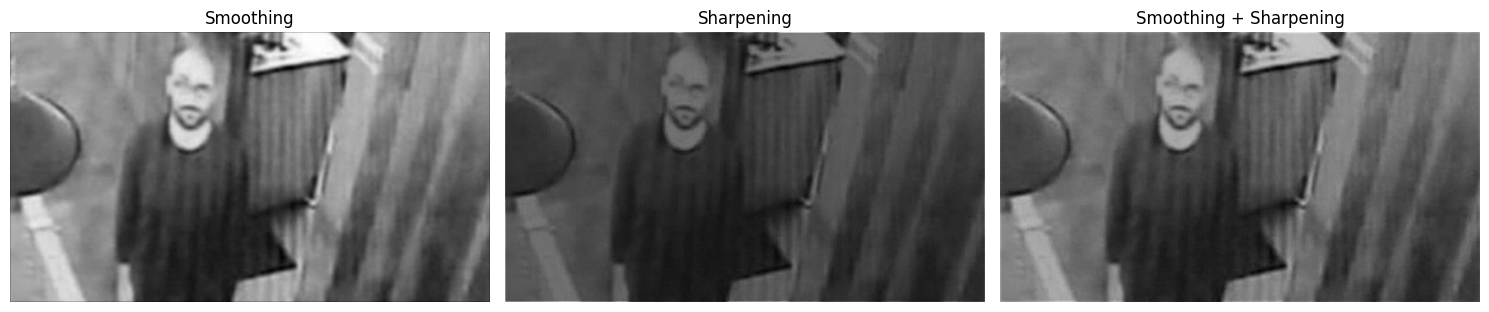

In [161]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

smoothed = convolution(img1, kernelSmoothing)

sharpened = convolution(img1, kernelSharpening)

smooth_sharp = convolution(smoothed, kernelSharpening)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(smoothed,     cmap='gray'); axes[0].set_title('Smoothing');             axes[0].axis('off')
axes[1].imshow(sharpened,    cmap='gray'); axes[1].set_title('Sharpening');            axes[1].axis('off')
axes[2].imshow(smooth_sharp, cmap='gray'); axes[2].set_title('Smoothing + Sharpening'); axes[2].axis('off')

plt.tight_layout()
plt.show()

In [119]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size

            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0

                    for val in region.ravel():
                        total += int(val)

                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()

                    tengah = len(values) // 2
                    canvas[i, j] = values[tengah]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().astype(np.uint8)

                    count = np.zeros(256, dtype=int)

                    for val in values:
                        count[val] += 1

                    canvas[i, j] = np.argmax(count)

    return canvas

Function filter digunakan untuk melakukan proses filtering menggunakan metode mean, median, dan modus. Function ini bekerja dengan teknik sliding window, yaitu kernel digeser ke seluruh bagian citra untuk mengambil area piksel tertentu lalu menghitungnya. Padding mode edge ditambahkan agar kernel tetap bisa berjalan di piksel tepi tanpa mengurangi dimensi output.

Mean filter menghitung rata-rata seluruh piksel pada area kernel untuk menghaluskan citra. Semakin besar ukuran kernel yang digunakan, maka efek blur pada citra akan semakin besar. Median filter mengambil nilai tengah dari piksel pada area kernel sehingga mampu mengurangi noise tanpa terlalu merusak tepi objek pada gambar. Modus filter mencari nilai piksel yang paling sering muncul pada area kernel sehingga area citra menjadi lebih seragam dan variasi intensitas kecil berkurang.

In [120]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

Pada bagian ini didefinisikan kernel-kernel deteksi tepi untuk tiga operator yang berbeda. Kernel Sobel berukuran 3x3 memiliki pembobotan lebih besar di baris dan kolom tengah (nilai ±2) sehingga lebih tahan terhadap noise dan menghasilkan tepi yang lebih tebal. Kernel Prewitt berukuran 3x3 menggunakan bobot seragam (nilai ±1) tanpa pembobotan tambahan sehingga lebih sensitif terhadap noise namun menghasilkan tepi yang sedikit lebih tipis. Kernel Roberts berukuran 2x2 mendeteksi perubahan kontras secara diagonal sehingga komputasinya paling cepat namun menghasilkan tepi paling tipis dan paling rentan terhadap noise dibanding dua operator lainnya.

In [ ]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    magnitude = np.abs(gx) + np.abs(gy)
    
    if np.max(magnitude) == 0:
        return np.zeros_like(img, dtype=np.uint8)
    magnitude = magnitude * 255.0 / np.max(magnitude)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

Function edge digunakan untuk menggabungkan hasil deteksi tepi dari arah horizontal (sumbu x) dan vertikal (sumbu y) menjadi satu peta tepi. Nilai absolut wajib diambil dari kedua hasil konvolusi sebelum dijumlahkan karena kernel deteksi tepi menghasilkan nilai negatif untuk transisi terang ke gelap, tanpa abs(), setengah tepi gambar akan hilang setelah dikonversi ke uint8. Hasil akhirnya kemudian dinormalisasi ke rentang 0-255 agar seluruh rentang nilai digunakan dan citra tepi dapat ditampilkan dengan kontras yang maksimal.

Pada tahap ini operator Sobel, Prewitt, Roberts diterapkan ke semua variasi citra hasil filter spasial. Setiap grid menampilkan tujuh variasi hasil deteksi tepi berdasarkan citra input yang berbeda-beda sehingga pengaruh kualitas citra input terhadap hasil deteksi tepi bisa diamati langsung. Kombinasi operator dilakukan dengan menjumlahkan hasil deteksi tepi lalu dinormalisasi, urutan penjumlahan tidak mengubah hasil matematika, tetapi pasangan operator yang berbeda dapat menonjolkan tepi yang berbeda karena masing-masing operator memiliki sensitivitas arah dan bobot yang tidak sama.

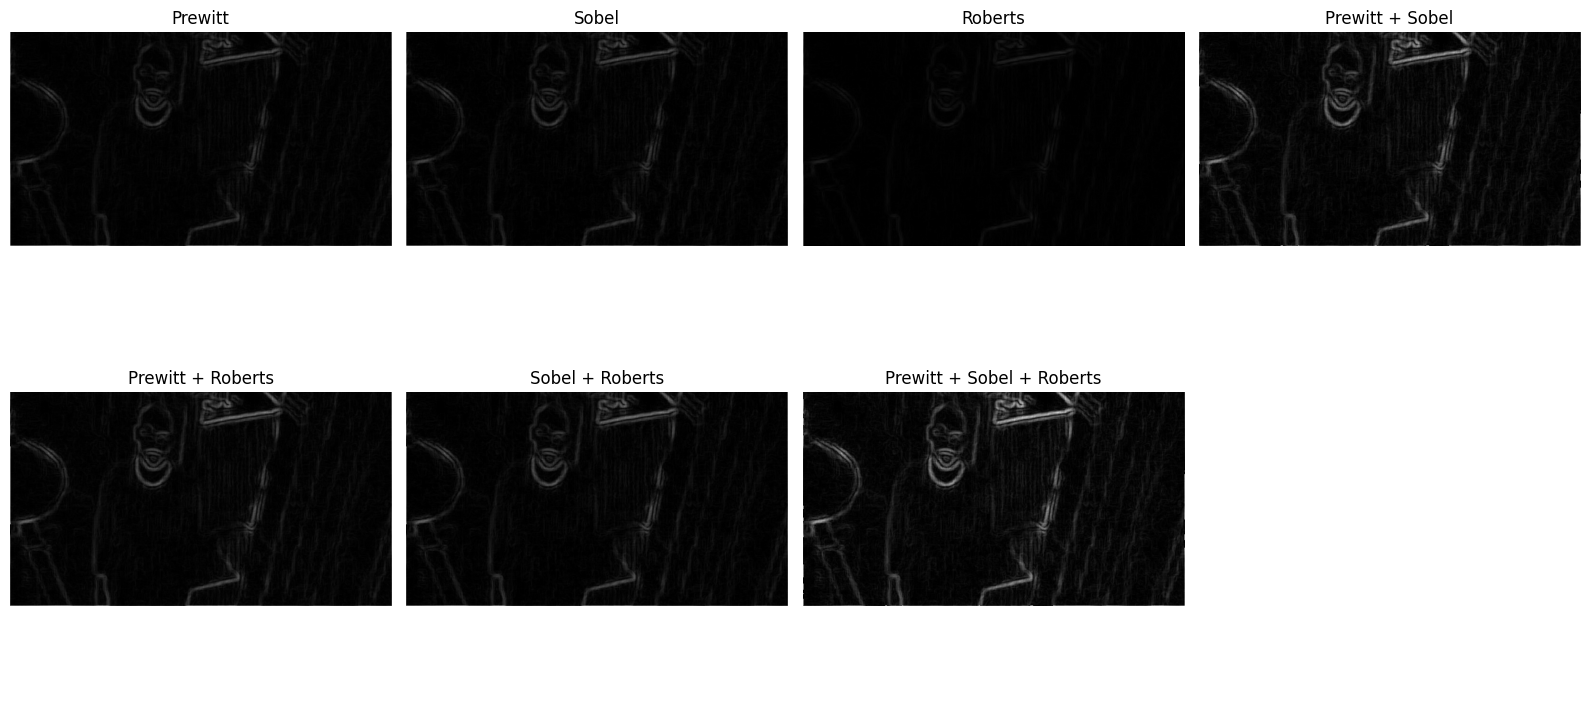

In [162]:
Prewitt = edge(img1, prewittX, prewittY)
Sobel = edge(img1, sobelX, sobelY)
Robert = edge(img1, robertsX, robertsY)

comb1 = Prewitt + Sobel
comb2 = Prewitt + Robert
comb3 = Sobel + Robert
comb4 = Prewitt + Sobel + Robert

norm1 = normalisasi(comb1)
norm2 = normalisasi(comb2)
norm3 = normalisasi(comb3)
norm4 = normalisasi(comb4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0][0].imshow(Prewitt, cmap='gray'); axes[0][0].set_title('Prewitt');               axes[0][0].axis('off')
axes[0][1].imshow(Sobel,   cmap='gray'); axes[0][1].set_title('Sobel');                 axes[0][1].axis('off')
axes[0][2].imshow(Robert,  cmap='gray'); axes[0][2].set_title('Roberts');               axes[0][2].axis('off')
axes[0][3].imshow(norm1,   cmap='gray'); axes[0][3].set_title('Prewitt + Sobel');       axes[0][3].axis('off')
axes[1][0].imshow(norm2,   cmap='gray'); axes[1][0].set_title('Prewitt + Roberts');     axes[1][0].axis('off')
axes[1][1].imshow(norm3,   cmap='gray'); axes[1][1].set_title('Sobel + Roberts');       axes[1][1].axis('off')
axes[1][2].imshow(norm4,   cmap='gray'); axes[1][2].set_title('Prewitt + Sobel + Roberts'); axes[1][2].axis('off')
axes[1][3].axis('off')

plt.tight_layout()
plt.show()

Pada tahap ini threshold diterapkan pada hasil deteksi tepi Sobel untuk menghasilkan citra biner hitam putih. Threshold berfungsi sebagai filter yang hanya mempertahankan piksel dengan nilai gradien di atas nilai tertentu sebagai tepi (putih) dan membuang sisanya sebagai background (hitam). Threshold rendah seperti 10 menghasilkan banyak garis tepi termasuk noise karena hampir semua piksel lolos, sedangkan threshold tinggi seperti 60 hanya mempertahankan tepi dengan perubahan intensitas yang sangat kuat sehingga banyak detail yang hilang. Nilai threshold terbaik untuk kasus CCTV ini adalah sekitar 20-30 karena masih mampu menangkap kontur utama orang dan objek tanpa terlalu banyak noise yang mengganggu.

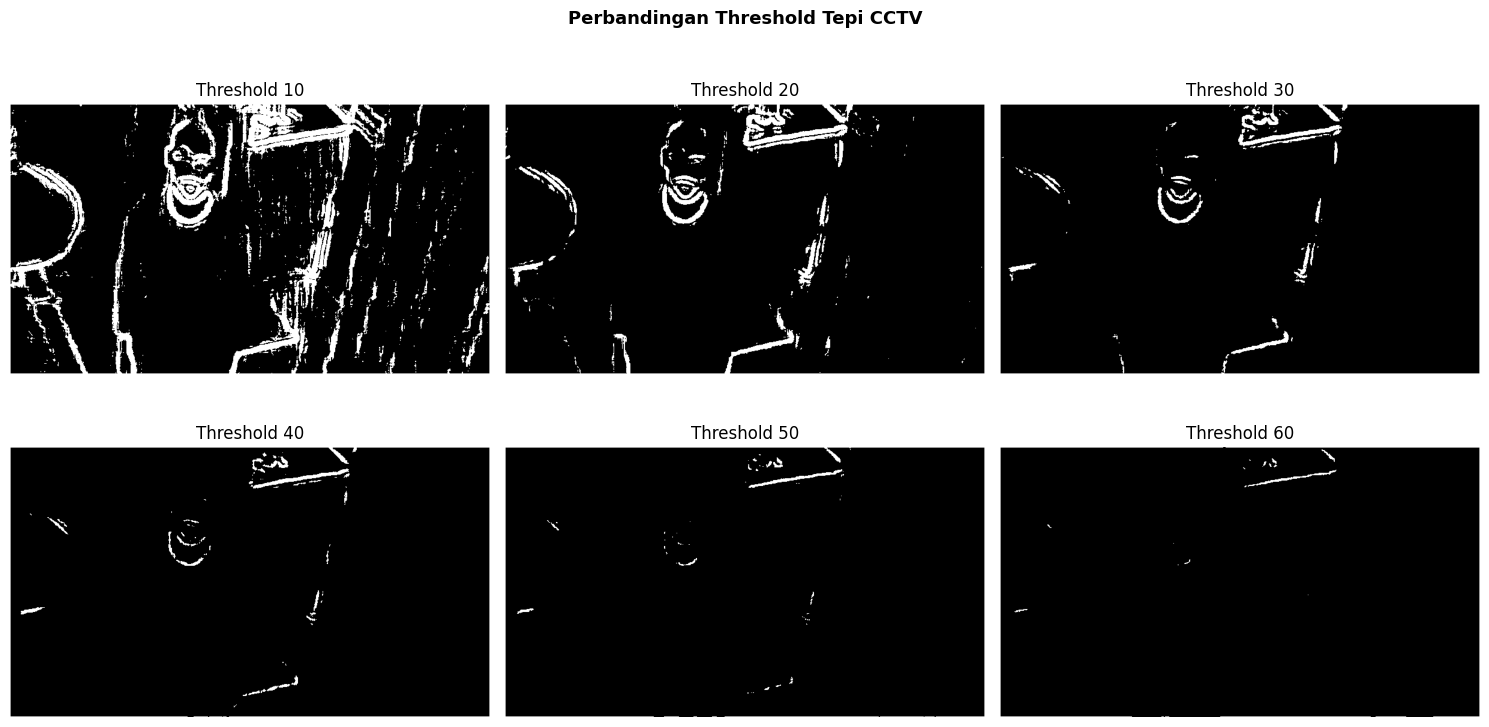

In [163]:
def thresholds(img, threshold=50):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = 255 if img[i, j] > threshold else 0
    return hasil

t10 = thresholds(Sobel, 10)
t20 = thresholds(Sobel, 20)
t30 = thresholds(Sobel, 30)
t40 = thresholds(Sobel, 40)
t50 = thresholds(Sobel, 50)
t60 = thresholds(Sobel, 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0][0].imshow(t10, cmap='gray'); axes[0][0].set_title('Threshold 10'); axes[0][0].axis('off')
axes[0][1].imshow(t20, cmap='gray'); axes[0][1].set_title('Threshold 20'); axes[0][1].axis('off')
axes[0][2].imshow(t30, cmap='gray'); axes[0][2].set_title('Threshold 30'); axes[0][2].axis('off')
axes[1][0].imshow(t40, cmap='gray'); axes[1][0].set_title('Threshold 40'); axes[1][0].axis('off')
axes[1][1].imshow(t50, cmap='gray'); axes[1][1].set_title('Threshold 50'); axes[1][1].axis('off')
axes[1][2].imshow(t60, cmap='gray'); axes[1][2].set_title('Threshold 60'); axes[1][2].axis('off')

plt.suptitle('Perbandingan Threshold Tepi CCTV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Pada tahap ini dilakukan highlight siluet orang pada citra CCTV menggunakan teknik masking. Masking digunakan untuk menandai area tertentu pada citra, dalam kasus ini mask dibuat dengan mendeteksi piksel yang memiliki karakteristik warna kulit atau warna baju di dalam zona koordinat orang. Area mask kemudian dihaluskan menggunakan median filter untuk mengurangi piksel noise yang terisolasi. Tepi dari mask yang sudah dihaluskan diambil menggunakan operator Sobel lalu di-threshold untuk mendapatkan garis kontur orang. Hasil akhirnya adalah overlay kuning pada area orang di gambar asli sehingga subjek lebih mudah dibaca secara visual.

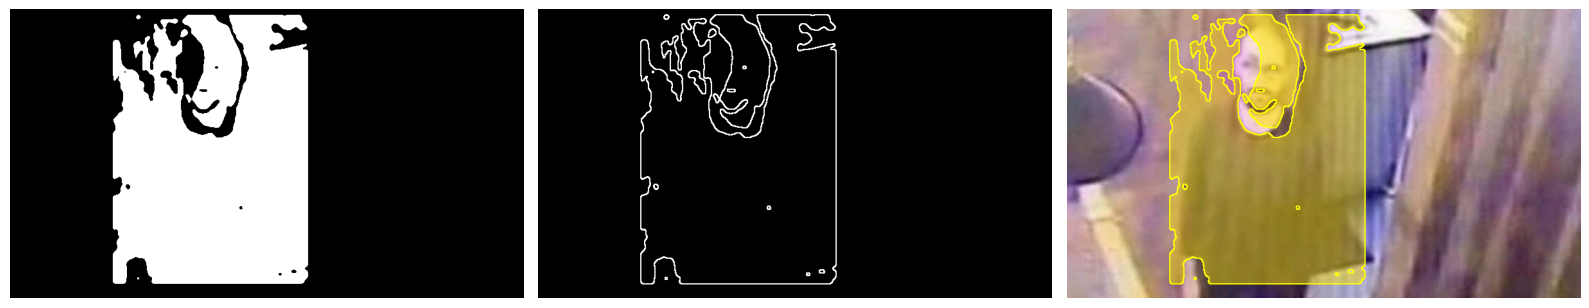

In [164]:
h, w = img1.shape
mask_orang = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        r = int(img1_rgb[i, j, 0])
        g = int(img1_rgb[i, j, 1])
        b = int(img1_rgb[i, j, 2])

        isKulit = (r > 150 and r - b > 50 and r - g > 10)
        isBaju  = (b > g and r < 180 and b > 50)

        if isKulit or isBaju:
            mask_orang[i, j] = 255

maskZone = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        if (int(0.02*h) <= i <= int(0.95*h) and
            int(0.20*w) <= j <= int(0.58*w)):
            maskZone[i, j] = mask_orang[i, j]

maskSmooth = filter(maskZone, 5, 'median')
maskSmooth= filter(maskSmooth, 5, 'median')

edgeMask = thresholds(edge(maskSmooth, sobelX, sobelY), 30)

highlight = img1_rgb.copy()
for i in range(h):
    for j in range(w):
        if maskSmooth[i, j] == 255:
            highlight[i, j, 0] = int(highlight[i, j, 0] * 0.55 + 255 * 0.45)
            highlight[i, j, 1] = int(highlight[i, j, 1] * 0.55 + 230 * 0.45)
            highlight[i, j, 2] = int(highlight[i, j, 2] * 0.55)
        if edgeMask[i, j] == 255:
            highlight[i, j] = [255, 255, 0]

# sudah sesuai format, tidak perlu diubah
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(maskSmooth, cmap='gray'); axes[0].axis('off')
axes[1].imshow(edgeMask,   cmap='gray'); axes[1].axis('off')
axes[2].imshow(highlight);               axes[2].axis('off')

plt.tight_layout()
plt.show()

Pada tahap ini citra david.jpg dibaca dan ditampilkan dalam dua bentuk, yaitu RGB asli dan grayscale. Berbeda dengan citra CCTV yang memiliki kualitas rendah, citra pas foto memiliki pencahayaan lebih baik sehingga tepi wajah, rambut, dan pakaian lebih mudah ditangkap oleh operator deteksi tepi.

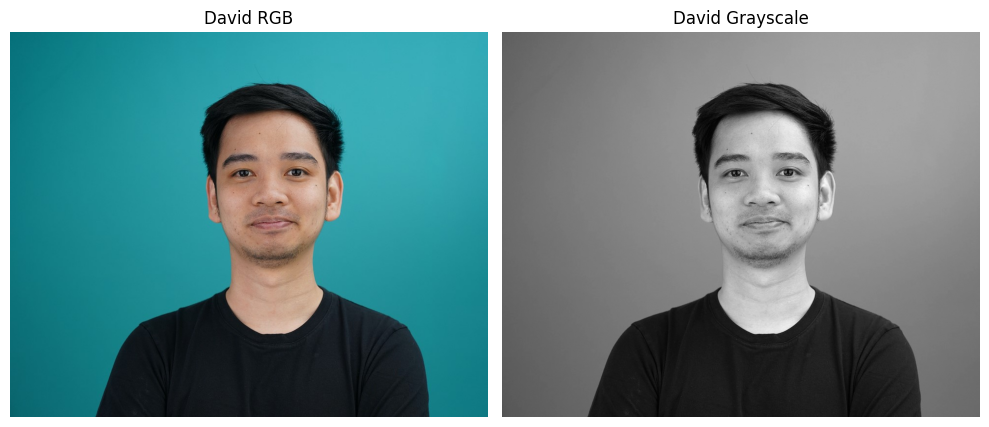

In [125]:
img2_bgr = cv2.imread('david.jpg')
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img2)
axes[0].set_title('David RGB')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('David Grayscale')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Pada tahap ini dilakukan dua proses sekaligus pada citra david.jpg, yaitu deteksi tepi wajah dan penghilangan background. Citra terlebih dahulu dihaluskan menggunakan median filter 3x3 untuk mengurangi noise sebelum deteksi tepi dilakukan, sehingga kontur wajah, rambut, dan pakaian bisa tertangkap dengan lebih bersih.

Untuk penghilangan background, pemisahan chanel RGB digunakan untuk mendeteksi background berwarna toska. Background dipisahkan berdasarkan perbandingan nilai channel merah, hijau, dan biru. Background toska memiliki nilai G dan B yang lebih tinggi dibanding R. Area foreground kemudian dipertahankan menggunakan foreground mask yang sudah dihaluskan dengan median filter, sedangkan area background diganti menjadi warna putih.

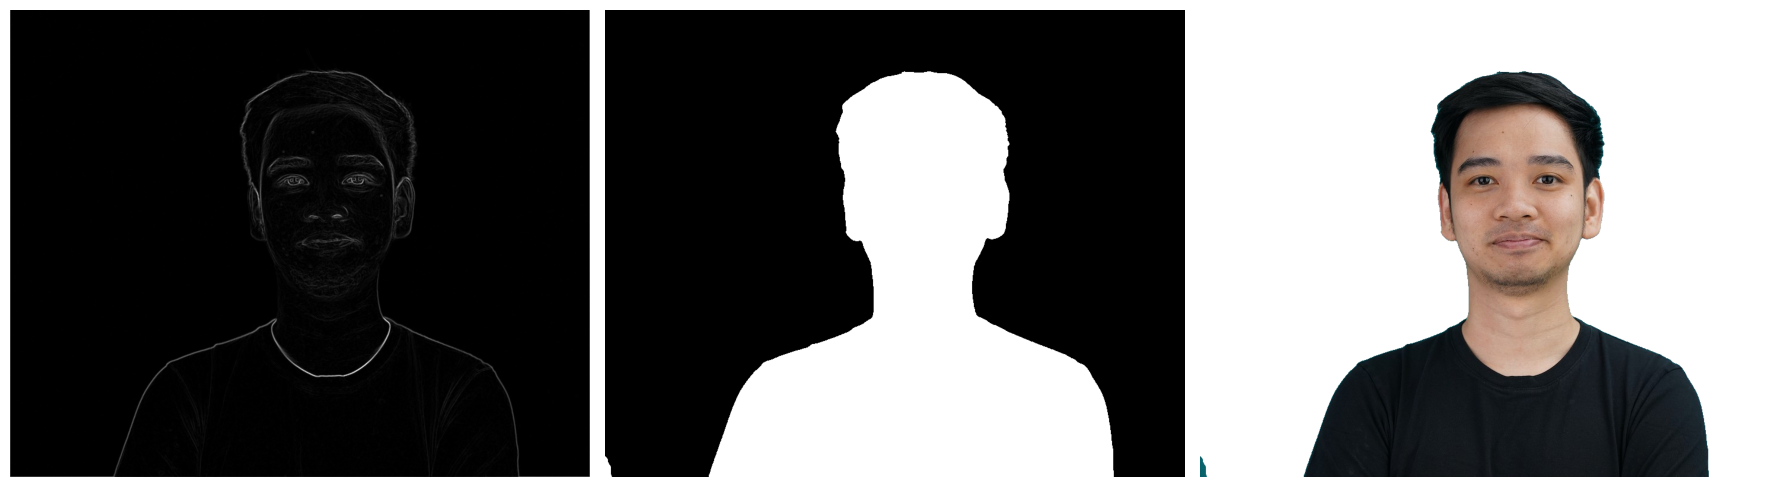

In [160]:
gray_smooth = filter(gray, 3, 'median')
david_edge = edge(gray_smooth, sobelX, sobelY)

R = img2[:, :, 0].astype(np.int32)
G = img2[:, :, 1].astype(np.int32)
B = img2[:, :, 2].astype(np.int32)

height, width = gray.shape
background_mask = np.zeros((height, width), dtype=np.uint8)
foreground_mask = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        is_background = (
            G[i, j] > 100 and
            B[i, j] > 100 and
            R[i, j] < 160 and
            G[i, j] - R[i, j] > 15 and
            B[i, j] - R[i, j] > 10
        )
        if is_background:
            background_mask[i, j] = 255
        else:
            foreground_mask[i, j] = 255

foreground_mask = filter(foreground_mask, 5, 'median')

hasil_bg_putih = np.ones_like(img2, dtype=np.uint8) * 255
for i in range(height):
    for j in range(width):
        if foreground_mask[i, j] == 255:
            hasil_bg_putih[i, j] = img2[i, j]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(david_edge, cmap='gray');  axes[0].axis('off')
axes[1].imshow(foreground_mask, cmap='gray');  axes[1].axis('off')
axes[2].imshow(hasil_bg_putih);         axes[2].axis('off')

plt.tight_layout()
plt.show()